## TASK 4: Sentiment Analysis

This section will focus on performing sentiment analysis on the `netflix_titles.csv` dataset. We will use Natural Language Processing (NLP) techniques to classify the 'description' column into positive, negative, or neutral sentiments.

In [1]:
import pandas as pd
import nltk
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/wordnet.zip')
except LookupError: # Corrected: Catch LookupError instead of nltk.downloader.DownloadError
    nltk.download('punkt')
    nltk.download('wordnet')
    nltk.download('omw-1.4')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


### 1. Load the Dataset

First, we'll load the `netflix_titles.csv` file into a pandas DataFrame and inspect its structure.

In [2]:
file_path = '/content/netflix_titles.csv'
df = pd.read_csv(file_path)

print("Dataset Head:")
display(df.head())

print("\nDataset Info:")
df.info()

Dataset Head:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021.0,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021.0,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021.0,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5398 entries, 0 to 5397
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       5398 non-null   object 
 1   type          5398 non-null   object 
 2   title         5397 non-null   object 
 3   director      3515 non-null   object 
 4   cast          4903 non-null   object 
 5   country       4735 non-null   object 
 6   date_added    5397 non-null   object 
 7   release_year  5397 non-null   float64
 8   rating        5397 non-null   object 
 9   duration      5397 non-null   object 
 10  listed_in     5397 non-null   object 
 11  description   5397 non-null   object 
dtypes: float64(1), object(11)
memory usage: 506.2+ KB


### 2. Perform Sentiment Analysis

We will define a function to classify the sentiment of the 'description' column using `TextBlob`. `TextBlob` returns a polarity score ranging from -1 (negative) to 1 (positive). We'll categorize these scores into 'Positive', 'Negative', and 'Neutral'.

In [3]:
def get_sentiment(text):
    if pd.isna(text):
        return 'Neutral' # Handle missing descriptions
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis to the 'description' column
df['sentiment'] = df['description'].apply(get_sentiment)

print("Sentiment Distribution:")
display(df['sentiment'].value_counts())

Sentiment Distribution:


,count
sentiment,
Positive,2800
Negative,1638
Neutral,960


### 3. Visualize Sentiment Distribution

Finally, let's visualize the distribution of sentiments across the Netflix titles to understand the overall emotional tone of the content descriptions.

/tmp/ipykernel_3984/1849803655.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis', order=['Positive', 'Neutral', 'Negative'])


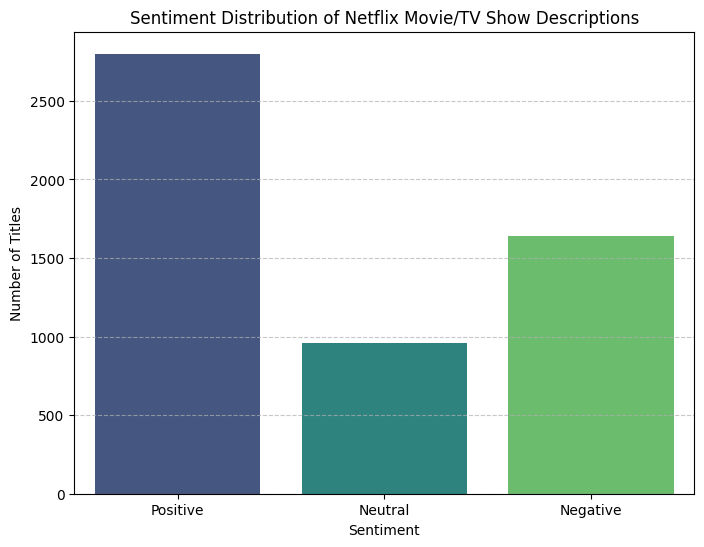

In [4]:
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df, palette='viridis', order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Distribution of Netflix Movie/TV Show Descriptions')
plt.xlabel('Sentiment')
plt.ylabel('Number of Titles')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 4. Examples of Descriptions by Sentiment

Let's look at some examples of descriptions for each sentiment category to understand what kind of text `TextBlob` classifies as positive, negative, or neutral.

In [5]:
print("\n--- Top 5 Positive Descriptions ---")
display(df[df['sentiment'] == 'Positive']['description'].head().tolist())

print("\n--- Top 5 Negative Descriptions ---")
display(df[df['sentiment'] == 'Negative']['description'].head().tolist())

print("\n--- Top 5 Neutral Descriptions ---")
display(df[df['sentiment'] == 'Neutral']['description'].head().tolist())


--- Top 5 Positive Descriptions ---


['As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.',
 "A talented batch of amateur bakers face off in a 10-week competition, whipping up their best dishes in the hopes of being named the U.K.'s best.",
 'Sicily boasts a bold "Anti-Mafia" coalition. But what happens when those trying to bring down organized crime are accused of being criminals themselves?',
 'After most of her family is murdered in a terrorist bombing, a young woman is unknowingly lured into joining the very group that killed them.',
 "When the clever but socially-awkward Tetê joins a new school, she'll do anything to fit in. But the queen bee among her classmates has other ideas."]


--- Top 5 Negative Descriptions ---


['To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war.',
 'Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series.',
 'On a photo shoot in Ghana, an American model slips back in time, becomes enslaved on a plantation and bears witness to the agony of her ancestral past.',
 'Students of color navigate the daily slights and slippery politics of life at an Ivy League college that\'s not nearly as "post-racial" as it thinks.',
 'In the late 1970s, an accused serial rapist claims multiple personalities control his behavior, setting off a legal odyssey that captivates America.']


--- Top 5 Neutral Descriptions ---


['After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth.',
 'In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life.',
 'The arrival of a charismatic young priest brings glorious miracles, ominous mysteries and renewed religious fervor to a dying town desperate to believe.',
 "Equestria's divided. But a bright-eyed hero believes Earth Ponies, Pegasi and Unicorns should be pals — and, hoof to heart, she’s determined to prove it.",
 "A woman adjusting to life after a loss contends with a feisty bird that's taken over her garden — and a husband who's struggling to find a way forward."]

### 5. Sentiment Analysis by Content Type

Now, let's explore if there's a difference in sentiment distribution between 'Movie' and 'TV Show' descriptions.

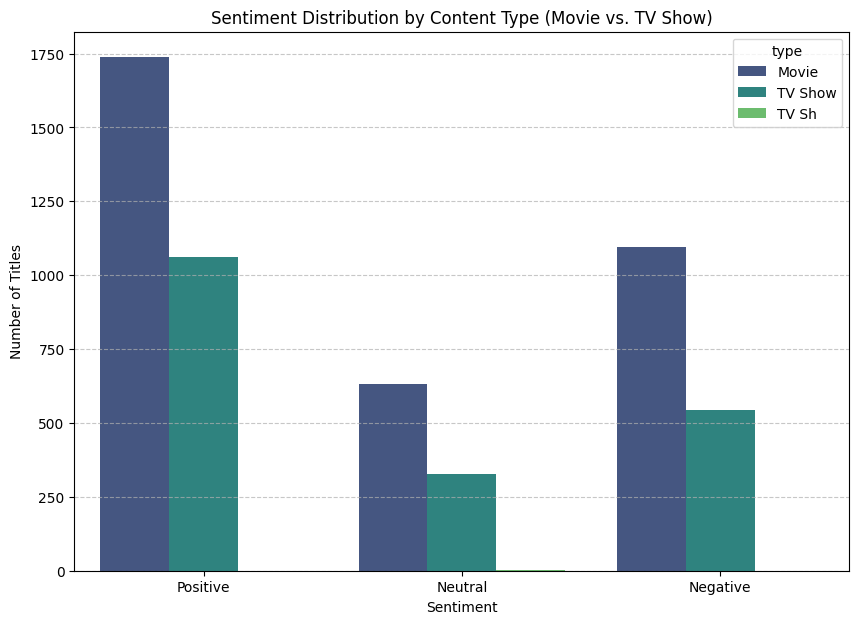

In [6]:
plt.figure(figsize=(10, 7))
sns.countplot(x='sentiment', hue='type', data=df, palette='viridis', order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Distribution by Content Type (Movie vs. TV Show)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Titles')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 6. Sentiment Analysis Over Time (by Release Year)

Let's see if the sentiment of descriptions has changed for content released over different years. For better visualization, we'll focus on recent years or group by periods if the data spans many decades.

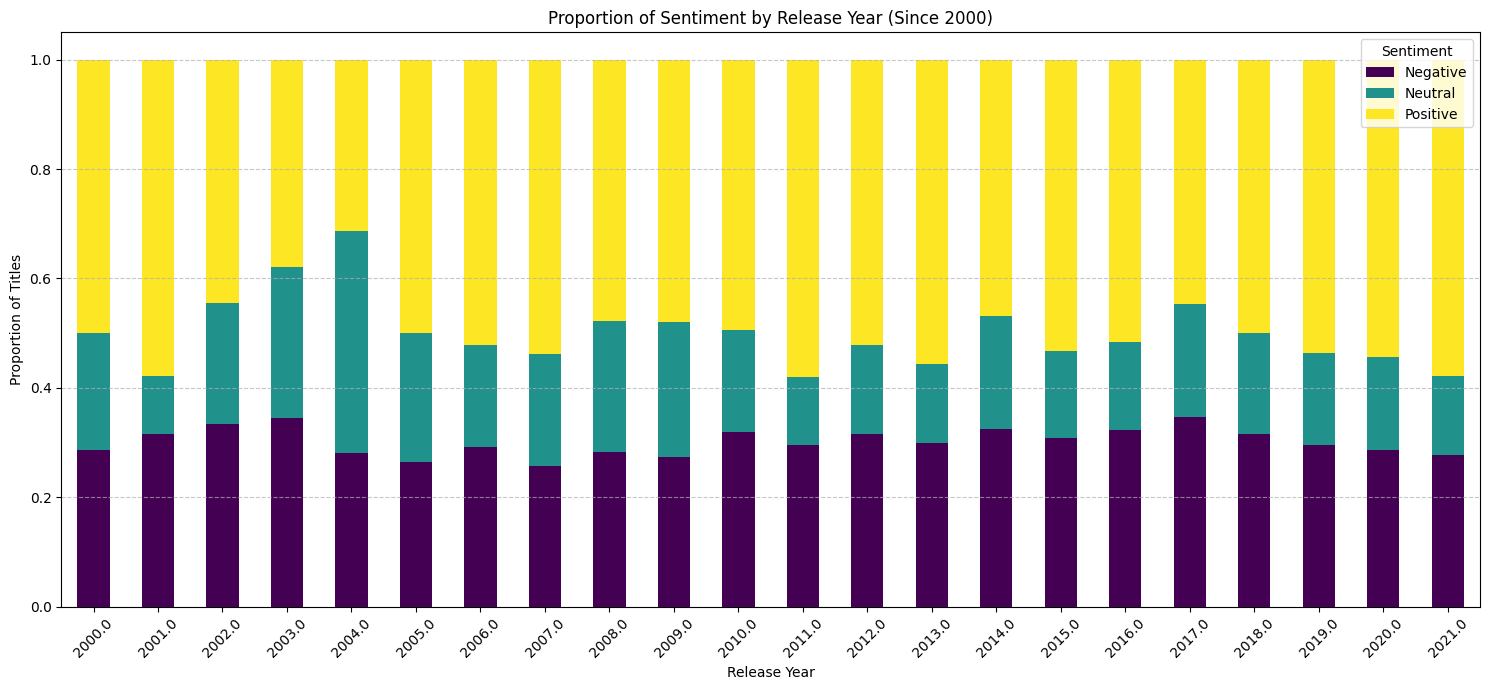

In [7]:
# Filter for a reasonable range of release years to visualize trends
recent_years_df = df[df['release_year'] >= 2000].copy()

sentiment_by_year = recent_years_df.groupby(['release_year', 'sentiment']).size().unstack(fill_value=0)
sentiment_by_year_normalized = sentiment_by_year.div(sentiment_by_year.sum(axis=1), axis=0)

sentiment_by_year_normalized.plot(kind='bar', stacked=True, figsize=(15, 7), colormap='viridis')
plt.title('Proportion of Sentiment by Release Year (Since 2000)')
plt.xlabel('Release Year')
plt.ylabel('Proportion of Titles')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

### Summary of Sentiment Analysis Findings

This analysis provides insights into the general tone of Netflix content descriptions. We've seen:
- The overall distribution of positive, negative, and neutral descriptions.
- Concrete examples of how descriptions are categorized.
- Differences in sentiment between Movies and TV Shows, if any.
- How sentiment trends in descriptions might have evolved over time based on release year.